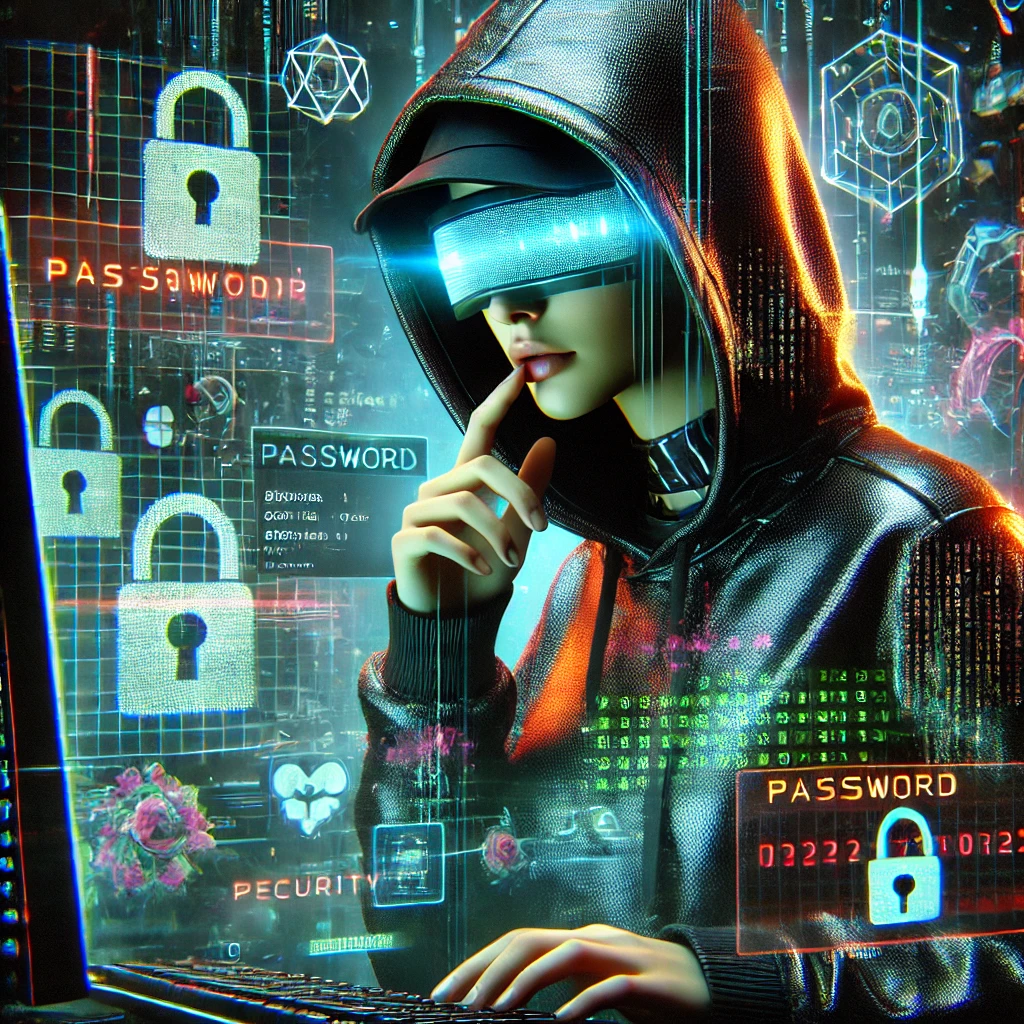

In [4]:
import random
import string
import hashlib
import operator
import time
import matplotlib.pyplot as plt



In [5]:
def generate_random_population(population_size, password_size):
    """
    Gera uma população inicial de indivíduos aleatórios com caracteres variados:
    letras maiúsculas, minúsculas, números e caracteres especiais.
    """
    # Define os caracteres possíveis para a senha
    letras_minusculas = string.ascii_lowercase  # abcdefghijklmnopqrstuvwxyz
    letras_maiusculas = string.ascii_uppercase  # ABCDEFGHIJKLMNOPQRSTUVWXYZ
    numeros = string.digits  # 0123456789
    especiais = "@#$%&*!?+-_"
    
    # Combina todos os caracteres em um único conjunto
    todos_caracteres = letras_minusculas + letras_maiusculas + numeros + especiais
    
    # Gera a população de senhas complexas
    populacao = []
    for _ in range(population_size):
        # Para cada senha, garantimos pelo menos um de cada tipo de caractere
        senha = [
            random.choice(letras_minusculas),
            random.choice(letras_maiusculas),
            random.choice(numeros),
            random.choice(especiais)
        ]
        
        # Completa o resto da senha com caracteres aleatórios
        for _ in range(password_size - 4):
            senha.append(random.choice(todos_caracteres))
        
        # Embaralha os caracteres para evitar um padrão previsível
        random.shuffle(senha)
        
        # Converte a lista de caracteres em uma string
        senha_str = ''.join(senha)
        
        populacao.append(senha_str)
    
    return populacao


In [6]:
def password_hash(password):
    """Retorna o hash SHA-256 de uma senha."""
    return hashlib.sha256(password.encode()).hexdigest()

In [7]:
#Gera uma população inicial de indivíduos aleatórios 

password = 'batman'
password_size = len(password)
target_hash = password_hash(password)
tam_senha = len(password)
tam_pop = 900
porcentagem_elitismo = 0.1 
elitistas = int(porcentagem_elitismo * tam_pop)
melhores = int(0.6 * tam_pop)
aleatorios = int(0.3 * tam_pop)
num_filhos = 2
taxa_mutacao = 95
max_geracoes = 10000  # Limite máximo de gerações para evitar loop infinito
historico_fitness = []
# Inicializa a população
print('Target: ', target_hash)
population = generate_random_population(tam_pop, tam_senha)
print('População: ', population)

Target:  1532e76dbe9d43d0dea98c331ca5ae8a65c5e8e8b99d3e2a42ae989356f6242a
População:  ['n$pGZ9', '8MV$Ol', 'Z+mU8&', '9$GqUC', '&e5K_x', '*98Q3u', '!4Xikd', 'G?qD4G', '3oPU%v', 'Jy*Xz2', 'i+Qr9H', '$dUCN9', '*7p6bR', '%Fc18o', 'Rnc-E9', '2qB1J#', 'n?Qd1i', '1DKv-e', 'eI_8#W', 'LnK-R4', 'xlQ-d6', '@Z8-oH', 'Ej$u04', 'I%oyL3', 'F8+Jsp', 'pk!Jg9', '-S1Q+g', '#t1F_g', '+I1Pd_', '*W53fj', '7gR3k@', 'Y-RgS0', 'hxFA2&', 'Id4_US', 'J1Aks&', 'cvY?3V', 'I51g!H', 'O-0zX6', 'MZ1a$B', 'Zbkp*2', 'u6YB!r', 'C2wFG@', 'r-X6Mp', '+#L7xt', '&DX*u5', 'o7ae_U', '5v$H$T', 'cDY4?%', '$5i&Fk', 't2U_?M', '0XxmC$', '2ghjF+', '76toN+', 'dP*7s*', '&3rxNP', 'SBz?8G', '@TB5Fb', 'ib@Xi5', '@Mb_9g', 'fcZ50$', '7YnE!p', 'c4yY#Q', '&74Ex_', '+sI+&8', '1+WuU*', '_l0hRc', '-$Z5&w', '*d4pOT', '1kB_!I', '?Kw9pr', 'c?3O7z', 'S7ivT$', '*ns5lO', 'ko_J+5', '3Kq0*T', 'wB2&Y2', '-3C!p3', 'x6Ht@8', 'xT&1Ja', '5VO*Tf', '_K84ci', '4bw*aX', 'riy-V9', 'X7u?9B', '5Ah9$P', 'Fm3$W%', 'PWU4e+', 'N6Al!V', 'Jk&E31', 'vQ9@78', 'AhdA#9', '-8

In [8]:
def calculate_fitness(population,target_hash):
    """Versão otimizada da avaliação de fitness da população considerando o Hash de cada individuo da pupulação."""
    # Pre-calcular os hashes uma vez só para cada indivíduo
    hashes = [password_hash(individuo) for individuo in population]
    
    # Calcular scores
    scores = {}
    for i, word_hash in enumerate(hashes):
        score = sum(1 for j in range(len(target_hash)) if target_hash[j] == word_hash[j])
        scores[i] = (score * 100) / len(target_hash)
    
    return sorted(scores.items(), key=operator.itemgetter(1), reverse=True)



In [9]:
#Seleciona indivíduos fazendo sua ordenação por Fitness
# Avalia a população
melhores_scores = []
pop_ordenada = calculate_fitness(population, target_hash)
melhor_score = pop_ordenada[0][1]
melhores_scores.append(melhor_score)
historico_fitness.append(melhor_score)
print('População Ordenada: ', pop_ordenada)
print('Melhor Score: ', melhor_score)
print('Melhores Scores: ', melhores_scores)


População Ordenada:  [(123, 18.75), (8, 15.625), (90, 15.625), (133, 15.625), (862, 15.625), (6, 14.0625), (13, 14.0625), (120, 14.0625), (268, 14.0625), (275, 14.0625), (634, 14.0625), (14, 12.5), (52, 12.5), (58, 12.5), (143, 12.5), (183, 12.5), (198, 12.5), (218, 12.5), (226, 12.5), (308, 12.5), (337, 12.5), (340, 12.5), (344, 12.5), (378, 12.5), (401, 12.5), (413, 12.5), (546, 12.5), (564, 12.5), (613, 12.5), (628, 12.5), (753, 12.5), (817, 12.5), (829, 12.5), (884, 12.5), (23, 10.9375), (27, 10.9375), (28, 10.9375), (77, 10.9375), (88, 10.9375), (105, 10.9375), (137, 10.9375), (150, 10.9375), (164, 10.9375), (165, 10.9375), (211, 10.9375), (213, 10.9375), (223, 10.9375), (241, 10.9375), (248, 10.9375), (252, 10.9375), (266, 10.9375), (267, 10.9375), (285, 10.9375), (296, 10.9375), (300, 10.9375), (310, 10.9375), (357, 10.9375), (359, 10.9375), (399, 10.9375), (415, 10.9375), (421, 10.9375), (442, 10.9375), (494, 10.9375), (502, 10.9375), (504, 10.9375), (509, 10.9375), (510, 10.93

In [10]:
def tournament_selection(pop, pop_scores, tamanho_torneio=3):
    """Seleciona indivíduos usando o método de torneio."""
    selecionados = []
    indices = list(pop_scores.keys())
    scores = list(pop_scores.values())
    
    for _ in range(len(pop)):
        # Selecionar índices aleatórios para o torneio
        competidores_idx = random.sample(range(len(indices)), min(tamanho_torneio, len(indices)))
        # Encontrar o melhor competidor
        melhor_idx = competidores_idx[0]
        for idx in competidores_idx[1:]:
            if pop_scores[indices[idx]] > pop_scores[indices[melhor_idx]]:
                melhor_idx = idx
        selecionados.append(pop[indices[melhor_idx]])
    
    return selecionados

In [11]:
def adaptative_mutate_rate(geracao, fitness_max, fitness_medio, geracao_max=1000, historico_fitness=None):
    """
    Ajusta a taxa de mutação com base no progresso do algoritmo, mantendo taxas altas
    enquanto não houver convergência significativa no fitness.
    
    Args:
        geracao: Número da geração atual
        fitness_max: Valor de fitness do melhor indivíduo
        fitness_medio: Valor médio de fitness da população
        geracao_max: Número máximo de gerações previsto
        historico_fitness: Lista com os valores de fitness_max das últimas gerações
    
    Returns:
        Taxa de mutação ajustada (percentual)
    """
    # Normaliza o progresso da geração (0 no início, 1 no final)
    progresso = geracao / geracao_max
    
    # Detecta estagnação observando a melhoria do fitness nas últimas gerações
    estagnado = False
    taxa_convergencia = 0
    
    if historico_fitness and len(historico_fitness) >= 20:
        # Calcula a taxa de melhoria nas últimas 20 gerações
        melhoria_recente = fitness_max - historico_fitness[-20]
        # Normaliza pela quantidade de gerações para ter taxa por geração
        taxa_convergencia = melhoria_recente / 20
        
        # Se a melhoria for muito pequena, considera-se estagnado
        if taxa_convergencia < 0.05:
            estagnado = True
    
    # Enquanto o fitness estiver abaixo de 50%, mantém uma taxa muito alta
    if fitness_max < 50:
        return 85
        
    # Se estivermos estagnados com fitness baixo ou médio, aumenta drasticamente a mutação
    if estagnado and fitness_max < 85:
        return 90  # Taxa muito alta para escapar da estagnação
        
    # Quando o fitness_max for maior que 95%, reduz para refinamento final
    if fitness_max > 95:
        if estagnado:
            # Mesmo com alto fitness, se estiver estagnado, ainda precisa de alguma mutação
            return 15
        return max(5, 15 * (1 - progresso))  # Diminui suavemente até um mínimo de 5%
        
    # Se a diferença entre fitness_max e fitness_medio for pequena, há convergência prematura
    diversidade = fitness_max - fitness_medio
    if diversidade < 3:
        # Pouca diversidade → taxa alta para evitar convergência prematura
        return min(95, 75 + 20 * progresso)
        
    # Ajuste baseado na diversidade da população - quanto menor a diversidade, maior a taxa
    fator_diversidade = max(0, (10 - diversidade) / 10)  # 0 para alta diversidade, 1 para baixa
    
    # Taxa base que começa alta e reduz gradualmente, modificada pela diversidade
    taxa_base = max(30, 70 - 30 * progresso * (1 - fator_diversidade))
    
    # Taxa final ajustada pela convergência recente - se não estiver melhorando, aumenta taxa
    if taxa_convergencia < 0.2 and fitness_max < 90:
        return min(90, taxa_base + 20)
        
    return taxa_base

In [12]:
# Aplica elitismo - mantém os melhores indivíduos
# Calcula fitness médio para uso na taxa de mutação adaptativa
geracao = 0
fitness_medio = sum(score for _, score in pop_ordenada) / len(pop_ordenada)
        
# Ajusta a taxa de mutação
taxa_mutacao = adaptative_mutate_rate(geracao, melhor_score, fitness_medio, max_geracoes, historico_fitness)
        
# Cria dicionário de scores para seleção por torneio
pop_scores = {idx: score for idx, score in pop_ordenada}
        
# Aplica elitismo - mantém os melhores indivíduos
elite = [population[pop_ordenada[i][0]] for i in range(elitistas)]
        
# Seleciona o resto da população usando torneio
pop_selecionada = tournament_selection(population, pop_scores, tamanho_torneio=3)
print('Fitness Médio: ', fitness_medio)
print('Taxa de Mutação: ', taxa_mutacao)
print('Scores da Seleção por torneio: ', pop_scores)
print('Elitismo: ', elite)
print('População Selecionada: ', pop_selecionada)

Fitness Médio:  6.149305555555555
Taxa de Mutação:  85
Scores da Seleção por torneio:  {123: 18.75, 8: 15.625, 90: 15.625, 133: 15.625, 862: 15.625, 6: 14.0625, 13: 14.0625, 120: 14.0625, 268: 14.0625, 275: 14.0625, 634: 14.0625, 14: 12.5, 52: 12.5, 58: 12.5, 143: 12.5, 183: 12.5, 198: 12.5, 218: 12.5, 226: 12.5, 308: 12.5, 337: 12.5, 340: 12.5, 344: 12.5, 378: 12.5, 401: 12.5, 413: 12.5, 546: 12.5, 564: 12.5, 613: 12.5, 628: 12.5, 753: 12.5, 817: 12.5, 829: 12.5, 884: 12.5, 23: 10.9375, 27: 10.9375, 28: 10.9375, 77: 10.9375, 88: 10.9375, 105: 10.9375, 137: 10.9375, 150: 10.9375, 164: 10.9375, 165: 10.9375, 211: 10.9375, 213: 10.9375, 223: 10.9375, 241: 10.9375, 248: 10.9375, 252: 10.9375, 266: 10.9375, 267: 10.9375, 285: 10.9375, 296: 10.9375, 300: 10.9375, 310: 10.9375, 357: 10.9375, 359: 10.9375, 399: 10.9375, 415: 10.9375, 421: 10.9375, 442: 10.9375, 494: 10.9375, 502: 10.9375, 504: 10.9375, 509: 10.9375, 510: 10.9375, 516: 10.9375, 558: 10.9375, 579: 10.9375, 583: 10.9375, 587: 10

In [13]:
def multipoint_Crossover(ind1, ind2, num_pontos=2):
    """Realiza crossover com múltiplos pontos de corte."""
    pontos = sorted(random.sample(range(len(ind1)), num_pontos))
    filho = ""
    ultimo_ponto = 0
    
    for i, ponto in enumerate(pontos + [len(ind1)]):
        if i % 2 == 0:
            filho += ind1[ultimo_ponto:ponto]
        else:
            filho += ind2[ultimo_ponto:ponto]
        ultimo_ponto = ponto
        
    return filho

In [14]:
def child_generate(pop, num_filhos):
    """Gera novos filhos a partir da população selecionada usando crossover de múltiplos pontos."""
    prox_pop = []
    for i in range(len(pop)//2):
        for _ in range(num_filhos):
            prox_pop.append(multipoint_Crossover(pop[i], pop[len(pop) - 1 - i], num_pontos=2))
    return prox_pop



In [15]:
# Gera nova população
num_filhos = 2
nova_pop = child_generate(pop_selecionada, num_filhos)
print('Geração dos filhos por Crossover: ', nova_pop)

Geração dos filhos por Crossover:  ['W#?4_l', 'W5K6tl', 'F1%1Cz', 'y1%TCz', '2S!7Qc', '2m+Quc', '&Y9*Va', '&I9wVa', 'jr@FY&', '4r8UY&', 'I79%8y', 'bBs%8y', 'i1Y_30', 'w?Y_30', 'D8r9V*', 'v5r1V*', 'Zbkc52', 'Zbkc*2', 'o60S%@', 'ob0S%@', '9-RgSv', '9$RO0v', 'P7KCC-', 'Pq4_y-', 'P@Y35w', '0@Hc5w', '2q4_%+', 'kqQHw+', '9zi&2U', 'Tzi-dU', 'Pt1F_5', 'P_1F_5', '$fGB44', 'w@rB44', 'jSqC?+', 'VSqz8+', 'H722J$', 'H72f#$', '-HO3My', '-HO6jy', 'H72fB$', 'yo0fJ$', '8P_saI', '8E*saI', 'n9fwJX', 'n7fqfX', 'YK5-#%', '9K5-#%', '4aQo@C', '4Ll7XC', 'gggbq#', 'A$gW4#', '8+7T$9', 'jZ7Th9', 'k%9P9Y', 'kE0X9Y', '0#9mpw', '0F-apw', '&nc-4j', 'R+tW4j', '$N%4yA', '$N%9yA', '2*rO1s', '2_!@Js', '-w_xX0', 'Mw8tX0', '&6dH0?', '#Y&Q0?', 'yR_Zh5', 'yR6Zh5', '+%a@28', 'E%ax28', 'j4$km-', 'LW8Gm-', 'b5R$+8', 'Rv!*Q8', 'OeR$+8', 'OvR$+8', '@TB5db', '@TBPdb', 'OR_4n_', 'LR_4t_', 'q$C0%_', '9eO0p_', '5Vd$4l', '5Vd$4l', 'Py*Xz2', 'JyHc52', 'JWYo9%', '4WLo9%', '_t?T4Y', '_t?m4Y', 'n0Ud1i', 'n?Qi*i', '3cv_Q1', '3cD$Q1', '2!s

In [16]:
def ind_mutate(individuo):
    """Aplica mutação a um indivíduo substituindo uma letra aleatória."""
    indice = random.randint(0, len(individuo) - 1)
    letra = random.choice(string.ascii_lowercase)
    return individuo[:indice] + letra + individuo[indice+1:]

In [17]:
def mutate(population, taxa):
    """Aplica mutação a alguns indivíduos da população."""
    return [ind_mutate(ind) if random.random() * 100 < taxa else ind for ind in population]



In [18]:
# Aplica mutação
nova_pop = mutate(nova_pop, taxa_mutacao)
print('Nova população por mutaçãor: ', nova_pop)

Nova população por mutaçãor:  ['W#?4_d', 'W5K6tl', 'F1%1Cu', 'y1pTCz', '2S!7Qc', '2m+Qlc', '&Y9*Va', '&I9wpa', 'lr@FY&', '4rfUY&', 'I79j8y', 'bBp%8y', 'i1m_30', 'w?s_30', 'D8r9Vo', 'v5rxV*', 'Zbfc52', 'Zbkc*v', 'v60S%@', 'obeS%@', 'o-RgSv', '9$Rb0v', 'P7KpC-', 'Pq4_yu', 'P@b35w', 'l@Hc5w', '2ql_%+', 'pqQHw+', 'hzi&2U', 'Tei-dU', 'Pt1F_5', 'Pn1F_5', '$fxB44', 'w@rx44', 'jlqC?+', 'VSqb8+', 'l722J$', 'H72d#$', 'uHO3My', '-HO6jy', 'H72fe$', 'co0fJ$', '8PisaI', 'cE*saI', 'p9fwJX', 'n7fjfX', 'YK5-#p', '9Kl-#%', '4aQv@C', '4Le7XC', 'wggbq#', 'A$gW4#', '8+7d$9', 'jZ7Thd', 'kc9P9Y', 'kE0X9Y', '0#9mpw', '0F-spw', '&nc-yj', 'R+tb4j', 'yN%4yA', '$N%9yy', '2*rO1s', '2_!@Jh', '-w_xx0', 'Mt8tX0', 'o6dH0?', '#YmQ0?', 'yR_Zh5', 'ye6Zh5', 'y%a@28', 'E%ax28', 'j4$km-', 'LW8Gu-', 'bqR$+8', 'pv!*Q8', 'Oec$+8', 'Ovc$+8', '@rB5db', '@TBPdb', 'Oi_4n_', 'LRk4t_', 'q$C0%_', '9gO0p_', '5Vb$4l', '5Vd$4t', 'iy*Xz2', 'JcHc52', 'nWYo9%', 'iWLo9%', '_t?z4Y', '_t?m4a', 'n0Ud1i', 'n?Qigi', '3fv_Q1', '3cDpQ1', '2!s+Ft',

In [19]:
def showing_progress(geracao, melhor_individuo, melhor_score, hash_alvo, taxa_mutacao, intervalo=100):
    """Mostra informações de progresso periodicamente."""
    if geracao % intervalo == 0:
        print(f"Geração {geracao}:")
        print(f"Taxa Mutacao {taxa_mutacao}:")
        print(f"  Melhor indivíduo: {melhor_individuo}")
        print(f"  Fitness: {melhor_score:.2f}%")
        print(f"  Hash alvo (primeiros 8): {hash_alvo[:8]}")
        print(f"  Hash atual (primeiros 8): {password_hash(melhor_individuo)[:8]}")
        print("-" * 50)

In [20]:
def save_results(melhores_scores, tempo_total, senha_encontrada, geracoes):
    """Salva os resultados da execução em um arquivo."""
    with open("resultados_ga.txt", "w") as f:
        f.write(f"Senha encontrada: {senha_encontrada}\n")
        f.write(f"Hash correspondente: {password_hash(senha_encontrada)}\n")
        f.write(f"Número de gerações: {geracoes}\n")
        f.write(f"Tempo total: {tempo_total:.4f} segundos\n")
        f.write("\nMelhores scores por geração:\n")
        for i, score in enumerate(melhores_scores):
            if i % 100 == 0 or i == len(melhores_scores) - 1:
                f.write(f"Geração {i}: {score:.2f}%\n")

Geração 0:
Taxa Mutacao 95:
  Melhor indivíduo: %Ull5m
  Fitness: 15.62%
  Hash alvo (primeiros 8): 1532e76d
  Hash atual (primeiros 8): b2e0be9a
--------------------------------------------------
Geração 500:
Taxa Mutacao 85:
  Melhor indivíduo: docnbu
  Fitness: 26.56%
  Hash alvo (primeiros 8): 1532e76d
  Hash atual (primeiros 8): 1172bfa0
--------------------------------------------------
Geração 1000:
Taxa Mutacao 85:
  Melhor indivíduo: saqnoc
  Fitness: 31.25%
  Hash alvo (primeiros 8): 1532e76d
  Hash atual (primeiros 8): 75d21c18
--------------------------------------------------

RESULTADOS FINAIS:
Senha encontrada: batman
Hash correspondente: 1532e76dbe9d43d0dea98c331ca5ae8a65c5e8e8b99d3e2a42ae989356f6242a
Número de gerações: 1307
Tempo total de execução: 1339.1100 segundos


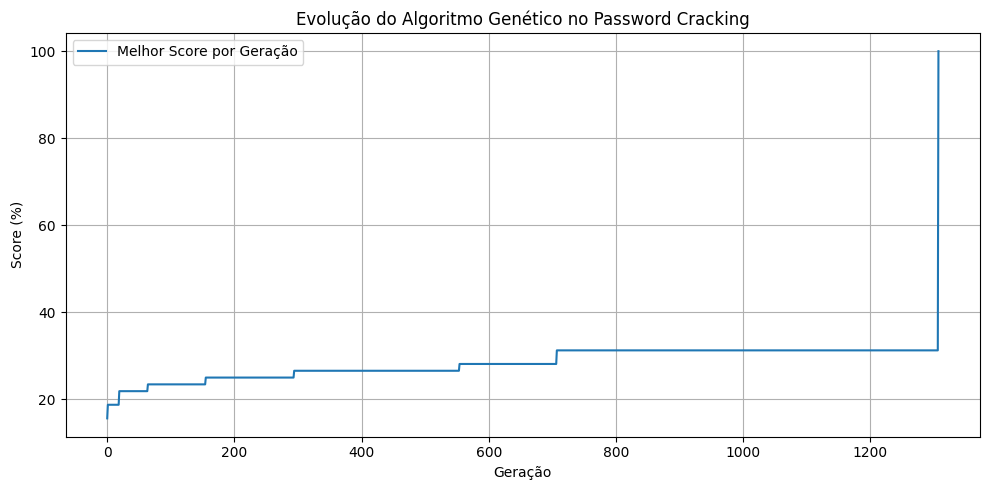

In [21]:
if __name__ == '__main__':
    # Gerar uma senha aleatória e calcular o hash (simulando um sistema real)
    password = 'batman'  # Ou use uma senha aleatória: ''.join(random.choice(string.ascii_lowercase) for _ in range(10))
    target_hash = password_hash(password)
    
    # Configurações
    tam_senha = len(password)
    tam_pop = 900
    porcentagem_elitismo = 0.1
    elitistas = int(porcentagem_elitismo * tam_pop)
    melhores = int(0.6 * tam_pop)
    aleatorios = int(0.3 * tam_pop)
    num_filhos = 2
    taxa_mutacao = 95
    max_geracoes = 10000  # Limite máximo de gerações para evitar loop infinito
    historico_fitness = []

    # Inicializa a população
    pop = generate_random_population(tam_pop, tam_senha)
    
    # Armazena os scores para visualização
    melhores_scores = []
    
    # Inicia a contagem do tempo
    total_time_start = time.time()
    
    geracao = 0
    encontrou_senha = False
    
    # Loop principal do algoritmo genético
    while not encontrou_senha and geracao < max_geracoes:
        # Avalia a população
        pop_ordenada = calculate_fitness(pop, target_hash)
        melhor_score = pop_ordenada[0][1]
        melhores_scores.append(melhor_score)
        historico_fitness.append(melhor_score)
        # Limita o tamanho do histórico para não consumir muita memória
        if len(historico_fitness) > 100:
            historico_fitness = historico_fitness[-100:]
        # Verifica se encontrou a senha
        melhor_individuo = pop[pop_ordenada[0][0]]
        if password_hash(melhor_individuo) == target_hash:
            encontrou_senha = True
            break
        
        # Mostra o progresso
        showing_progress(geracao, melhor_individuo, melhor_score, target_hash, taxa_mutacao, intervalo=500)
        
        # Calcula fitness médio para uso na taxa de mutação adaptativa
        fitness_medio = sum(score for _, score in pop_ordenada) / len(pop_ordenada)
        
        # Ajusta a taxa de mutação
        taxa_mutacao = adaptative_mutate_rate(geracao, melhor_score, fitness_medio, max_geracoes, historico_fitness)
        
        # Cria dicionário de scores para seleção por torneio
        pop_scores = {idx: score for idx, score in pop_ordenada}
        
        # Aplica elitismo - mantém os melhores indivíduos
        elite = [pop[pop_ordenada[i][0]] for i in range(elitistas)]
        
        # Seleciona o resto da população usando torneio
        pop_selecionada = tournament_selection(pop, pop_scores, tamanho_torneio=3)
        
        # Gera nova população
        nova_pop = child_generate(pop_selecionada, num_filhos)
        
        # Aplica mutação
        nova_pop = mutate(nova_pop, taxa_mutacao)
        
        # Forma nova população combinando elite com nova geração
        pop = elite + nova_pop
        
        geracao += 1
    
    # Resultados finais
    total_time_end = time.time()
    total_time = total_time_end - total_time_start
    
    print("\nRESULTADOS FINAIS:")
    print('Senha encontrada:', melhor_individuo)
    print('Hash correspondente:', password_hash(melhor_individuo))
    print('Número de gerações:', geracao)
    print(f"Tempo total de execução: {total_time:.4f} segundos")
    
    # Salva os resultados em arquivo
    save_results(melhores_scores, total_time, melhor_individuo, geracao)
    
    # Gráfico da evolução do score
    plt.figure(figsize=(10, 5))
    plt.plot(melhores_scores, label="Melhor Score por Geração")
    plt.xlabel("Geração")
    plt.ylabel("Score (%)")
    plt.title("Evolução do Algoritmo Genético no Password Cracking")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig("evolucao_ga.png")  # Salva o gráfico como arquivo
    plt.show()
